Developed a fraud detection system using Random Forest and XGBoost on an imbalanced dataset. Applied EDA, SMOTE, ROC-AUC analysis, and threshold tuning to improve fraud detection performance and optimize precision-recall tradeoff.

In [108]:
!pip install pandas numpy seaborn matplotlib scikit-learn xgboost imbalanced-learn streamlit pyngrok joblib


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [109]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,recall_score,f1_score,precision_score,roc_auc_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [110]:
df=pd.read_csv('PS_20174392719_1491204439457_log.csv')

In [111]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [112]:
df.shape

(6362620, 11)

In [113]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [114]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


In [115]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [116]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [117]:
df.isnull().sum().sum()

np.int64(0)

In [118]:
df= df.dropna()

In [119]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [120]:
df.isnull().sum().sum()

np.int64(0)

In [121]:
df.duplicated().sum()

np.int64(0)

In [122]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [123]:
df['isFraud'].value_counts(normalize=True)*100

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

In [124]:
df.describe(include='object')

,type,nameOrig,nameDest
count,6362620,6362620,6362620
unique,5,6353307,2722362
top,CASH_OUT,C2098525306,C1286084959
freq,2237500,3,113


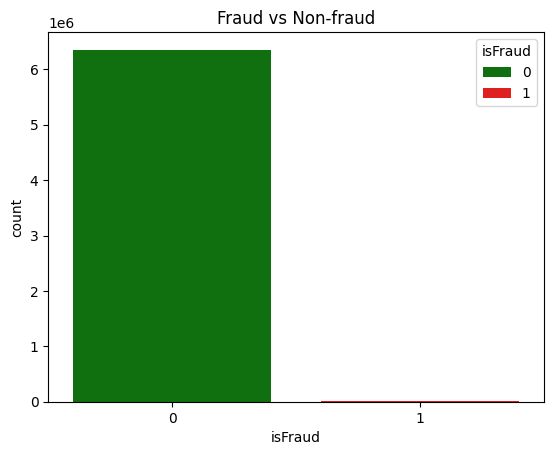

In [125]:
sns.countplot(data=df,x='isFraud',hue='isFraud', palette=['green', 'red'])
plt.title("Fraud vs Non-fraud")
plt.show()

In [126]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

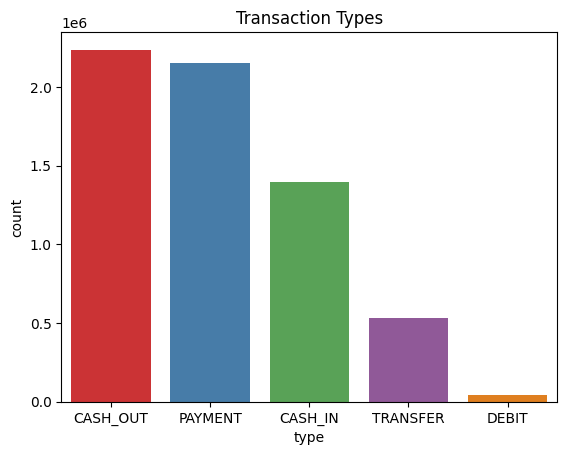

In [127]:
sns.countplot(data=df,x='type',order= df['type'].value_counts().index,palette='Set1')#orders the bars by frequency, from most common to least common.
plt.title('Transaction Types')
plt.show()

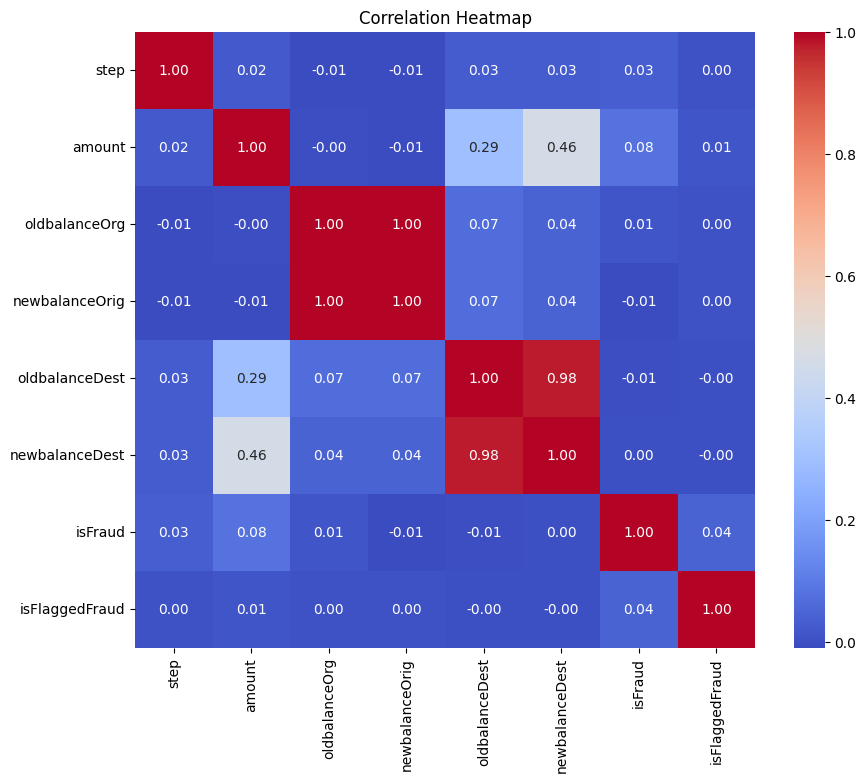

In [128]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
#see the exact correlation number printed inside each cell


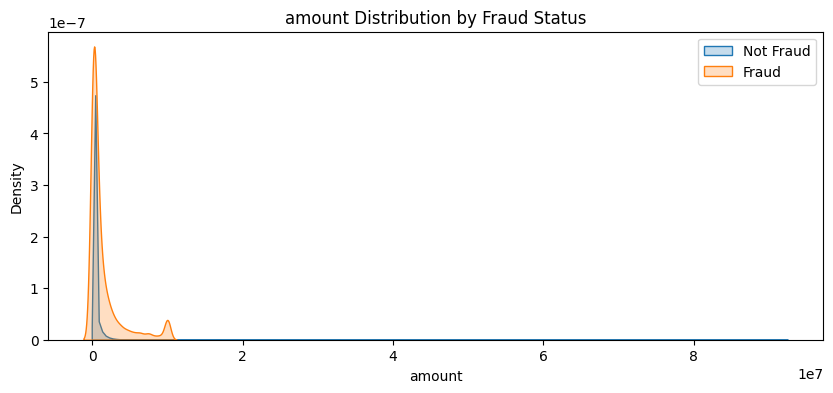

In [ ]:
cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
for col in cols:
    plt.figure(figsize=(10, 4))
    sns.kdeplot(df[df['isFraud']==0][col], label='Not Fraud', fill=True)
    sns.kdeplot(df[df['isFraud']==1][col], label='Fraud', fill=True)
    plt.title(f'{col} Distribution by Fraud Status')
    plt.legend()
    plt.show()
    #kdeplot stands for Kernel Density Estimate Plot. It’s a smoothed version of a histogram. Instead of showing bar heights (like histplot), it estimates the probability density function (PDF) of a variable.
#This helps you visually compare the distribution of each feature across the two classes.

In [ ]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [ ]:
le=LabelEncoder()


In [ ]:
df['type'] = le.fit_transform(df['type'])


In [ ]:
print(df.columns)

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFraud'],
      dtype='str')


In [ ]:
df.drop(
    columns=['nameOrig', 'nameDest', 'isFlaggedFraud'],
    inplace=True,
    errors='ignore'
)

In [ ]:
df

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,3,9839.64,170136.00,160296.36,0.00,0.00,0
1,1,3,1864.28,21249.00,19384.72,0.00,0.00,0
2,1,4,181.00,181.00,0.00,0.00,0.00,1
3,1,1,181.00,181.00,0.00,21182.00,0.00,1
4,1,3,11668.14,41554.00,29885.86,0.00,0.00,0
...,...,...,...,...,...,...,...,...
6362615,743,1,339682.13,339682.13,0.00,0.00,339682.13,1
6362616,743,4,6311409.28,6311409.28,0.00,0.00,0.00,1
6362617,743,1,6311409.28,6311409.28,0.00,68488.84,6379898.11,1
6362618,743,4,850002.52,850002.52,0.00,0.00,0.00,1


In [ ]:
X=df.drop('isFraud',axis=1)
y=df['isFraud']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from imblearn.over_sampling import SMOTE
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)
smote= SMOTE(random_state=42)
X_train_smote,y_train_smote= smote.fit_resample(X_train,y_train)



In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train_smote, y_train_smote)     #imp

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [ ]:
y_pred= model.predict(X_test)

In [ ]:
y_proba=model.predict_proba(X_test)[:,1]
#This returns a 2D array of probabilities.
#or a binary classification problem (0 = not fraud, 1 = fraud)
#You want fraud probability scores, not just 0/1

#AUC-ROC Curve

#Precision-Recall Curve

#Custom thresholds for classification

In [ ]:
custom_threshold=0.90
y_pred=(y_proba> custom_threshold).astype(int)

In [ ]:
print("Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.9894618883415951
              precision    recall  f1-score   support

           0       1.00      0.99      0.99   1906322
           1       0.09      0.75      0.16      2464

    accuracy                           0.99   1908786
   macro avg       0.54      0.87      0.57   1908786
weighted avg       1.00      0.99      0.99   1908786



In [ ]:
y_proba = model.predict_proba(X_test)[:, 1]# [:, 1]
#Selects the probability of class 1 — i.e., fraud probability.
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))
# Area Under the Receiver Operating Characteristic Curve.
#tells how well your model separates fraud vs non-fraud across all possible thresholds.

ROC AUC Score: 0.9723785036777559


In [ ]:
print(X_train_smote.shape)
print(y_train_smote.shape)

(8896170, 7)
(8896170,)


In [ ]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99   1906322
           1       0.09      0.75      0.16      2464

    accuracy                           0.99   1908786
   macro avg       0.54      0.87      0.57   1908786
weighted avg       1.00      0.99      0.99   1908786

ROC AUC: 0.9723785036777559


In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
randomforest_model= RandomForestClassifier()


In [ ]:
randomforest_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
#randomforest_model= RandomForestClassifier(n_estimators=300,max_depth=10,min_samples_leaf=5,class_weight='balanced',random_state=42)


In [ ]:
randomforest_model.fit(X_train_smote,y_train_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [ ]:
y_pred = randomforest_model.predict(X_test)

y_proba = randomforest_model.predict_proba(X_test)[:,1]

In [ ]:
thresholds = [0.3, 0.5, 0.7, 0.9]

print("RandomForest Threshold tuning results:\n")

for t in thresholds:

    y_pred_thresh = (y_proba > t).astype(int)

    acc = accuracy_score(y_test, y_pred_thresh)

    report = classification_report(
        y_test,
        y_pred_thresh,
        digits=4,
        output_dict=True
    )

    precision = report['1']['precision']
    recall = report['1']['recall']
    f1 = report['1']['f1-score']

    print(f"Threshold: {t}")

    print(f"Accuracy : {acc:.4f}")

    print(f"Precision (Fraud): {precision:.4f}")

    print(f"Recall (Fraud): {recall:.4f}")

    print(f"F1-score (Fraud): {f1:.4f}")

    print("-" * 40)

RandomForest Threshold tuning results:

Threshold: 0.3
Accuracy : 0.9666
Precision (Fraud): 0.0369
Recall (Fraud): 0.9927
F1-score (Fraud): 0.0712
----------------------------------------
Threshold: 0.5
Accuracy : 0.9851
Precision (Fraud): 0.0784
Recall (Fraud): 0.9817
F1-score (Fraud): 0.1453
----------------------------------------
Threshold: 0.7
Accuracy : 0.9944
Precision (Fraud): 0.1813
Recall (Fraud): 0.9602
F1-score (Fraud): 0.3050
----------------------------------------
Threshold: 0.9
Accuracy : 0.9995
Precision (Fraud): 0.8161
Recall (Fraud): 0.8340
F1-score (Fraud): 0.8250
----------------------------------------


In [ ]:
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99   1906322
           1       0.08      0.98      0.15      2464

    accuracy                           0.99   1908786
   macro avg       0.54      0.98      0.57   1908786
weighted avg       1.00      0.99      0.99   1908786

ROC AUC: 0.9985809510859334


In [ ]:
custom_threshold= 0.9
y_pred_thresh= (y_proba > custom_threshold).astype(int)
print(classification_report(y_test,y_pred_thresh))
print("ROC AUC:", roc_auc_score(y_test,y_proba))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.82      0.83      0.82      2464

    accuracy                           1.00   1908786
   macro avg       0.91      0.92      0.91   1908786
weighted avg       1.00      1.00      1.00   1908786

ROC AUC: 0.9985809510859334


In [ ]:
#from sklearn.calibration import CalibratedClassifierCV

In [ ]:
#calibrated_rf= CalibratedClassifierCV(model,method='sigmoid',cv=3)
#calibrated_rf.fit(X_train,y_train)

In [ ]:
#y_proba_cal= calibrated_rf.predict_proba(X_test)[:,1]

In [ ]:
#from collections import Counter
# y_train class distribution
#print("Label distribution in y_train:")
#print(Counter(y_train))
# imbalance ratio (majority / minority)
#class_imbalance_ratio = Counter(y_train)[0] / Counter(y_train)[1]
#print("Class imbalance ratio:", class_imbalance_ratio)


In [ ]:
#print(X_train.dtypes[X_train.dtypes == 'object'])


In [ ]:
#X_train = X_train.select_dtypes(include=[int, float, bool])
#X_test = X_test.select_dtypes(include=[int, float, bool])


In [ ]:
class_imbalance_ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train_smote, y_train_smote)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

y_proba = xgb.predict_proba(X_test)[:, 1]
y_pred = (y_proba > 0.4).astype(int)  # Custom threshold for fraud

print(classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      1.00      0.05      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.97      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786

ROC AUC Score: 0.9986516608912379


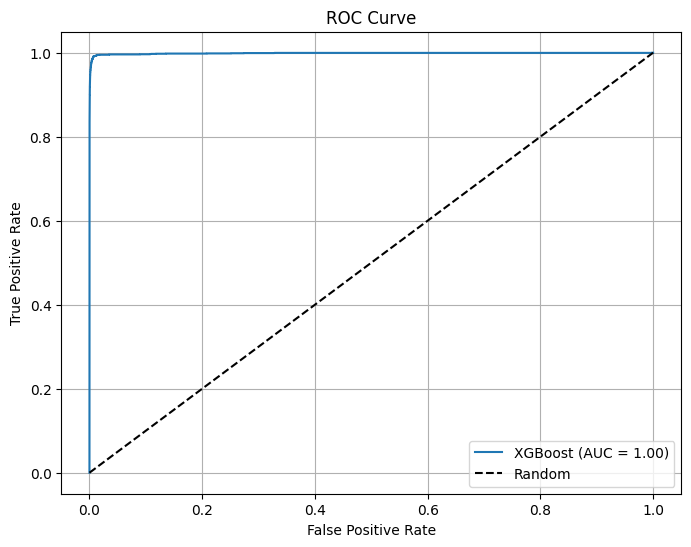

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()


In [ ]:
print(X_train.columns.tolist())

['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']


In [ ]:
print(randomforest_model.feature_names_in_.tolist())

['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']


In [ ]:
import joblib
joblib.dump(randomforest_model, "fraud_model.pkl")

In [ ]:
loaded_model = joblib.load("fraud_model.pkl")

In [ ]:
new_input = {
    'step': 1,
    'type': 'TRANSFER',
    'amount': 950000.0,
    'oldbalanceOrg': 950000.0,
    'newbalanceOrig': 0.0,
    'oldbalanceDest': 0.0,
    'newbalanceDest': 0.0
}

new_df = pd.DataFrame([new_input])

# Encode transaction type
new_df['type'] = le.transform(new_df['type'])

# Match training feature order
new_df = new_df[randomforest_model.feature_names_in_]

# Fraud probability
fraud_probability = randomforest_model.predict_proba(new_df)[0][1]

threshold = 0.9

if fraud_probability > threshold:
    print("Fraudulent Transaction")
else:
    print("Legitimate Transaction")

print(f"Fraud Probability: {fraud_probability:.2f}")

Fraudulent Transaction
Fraud Probability: 0.91


In [ ]:
#Final Model Selected
#Model: Random Forest
#Optimal Threshold: 0.9
# F1-Score: 0.83
# ROC-AUC: 0.9985
# Deployed via Streamlit with 3-tier risk scoring